In [112]:
import pandas as pd
import matplotlib.pyplot as plt

 - Função `read_csv` utilizado para ler o DataBase

 - Função `duplicated(). sum()` utilizado para contar quantas linhas duplicadas tem no BataBase 

 - Função `drop_duplicates()` utilizado para remover as linhas duplicadas 


In [113]:
dados_google = pd.read_csv('googleplaystore.csv')

dados_google.shape


(10841, 13)

In [114]:
dados_google.duplicated().sum()

np.int64(483)

In [115]:
dados_google_Atualizado = dados_google.drop_duplicates()

dados_google_Atualizado.shape

(10358, 13)


 - Função `str.replace()` utilizado para remover caracteres como `+` e `,` da coluna `Installs` e `str.strip()` para remover espaços vazios 

 - Função `str.isdigit()` utilizado para ignorar qualquer valor que não seja númerico na coluna `Installs`

 - Função `astype()` utilzado para converter a coluna `Installs` para `Int` 


In [116]:
dados_google_Atualizado['Installs'] = dados_google_Atualizado['Installs'].str.replace('[+,]', '', regex=True).str.strip()

dados_google_Atualizado = dados_google_Atualizado[dados_google_Atualizado['Installs'].str.isdigit()]

dados_google_Atualizado['Installs'] = dados_google_Atualizado['Installs'].astype(int)


C:\Users\proge\AppData\Local\Temp\ipykernel_12640\3862061462.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_google_Atualizado['Installs'] = dados_google_Atualizado['Installs'].str.replace('[+,]', '', regex=True).str.strip()


 - Função `nlargest()` utilizado para mostrar as 5 maiores Instalações, baseado na coluna `Installs` e na `App` que contem o nome dos aplicativos

In [117]:
top_aplicativos = dados_google_Atualizado.nlargest(5, 'Installs')[['App', 'Installs']]

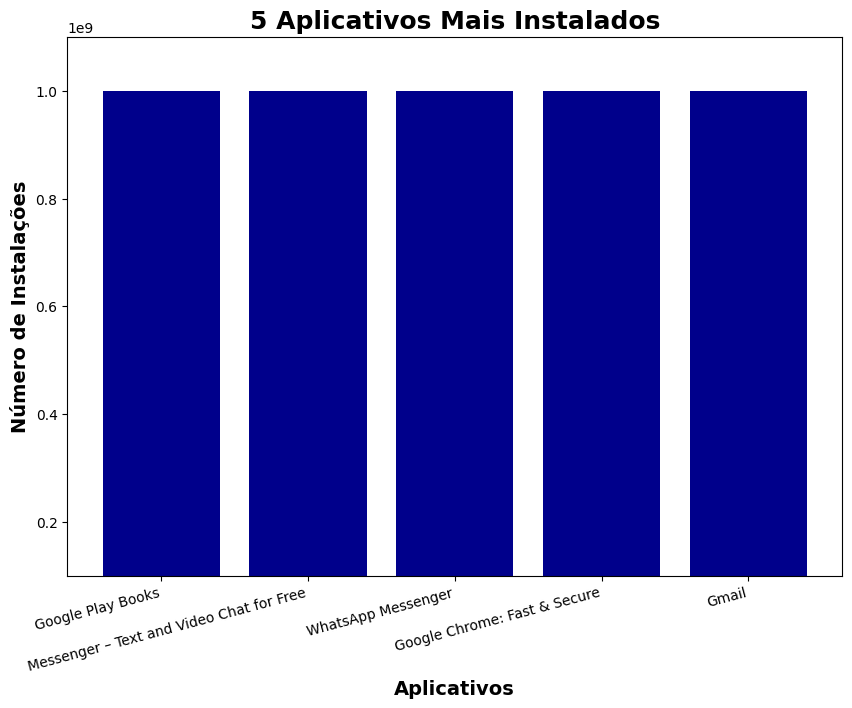

In [118]:
plt.figure(figsize=(10, 7))
plt.bar(top_aplicativos['App'], top_aplicativos['Installs'], color='darkblue')
plt.title('5 Aplicativos Mais Instalados', fontsize=18, fontweight='bold')
plt.xlabel('Aplicativos', fontsize=14, fontweight='bold')
plt.ylabel('Número de Instalações', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=10)

plt.ylim(1e8, top_aplicativos['Installs'].max() * 1.1)
plt.show()

 - Função `value_counts()` utilizado para fazer a contagem de cada valor que foi inserido na coluna `Category`

In [119]:
quantidades_categorias = dados_google_Atualizado['Category'].value_counts()

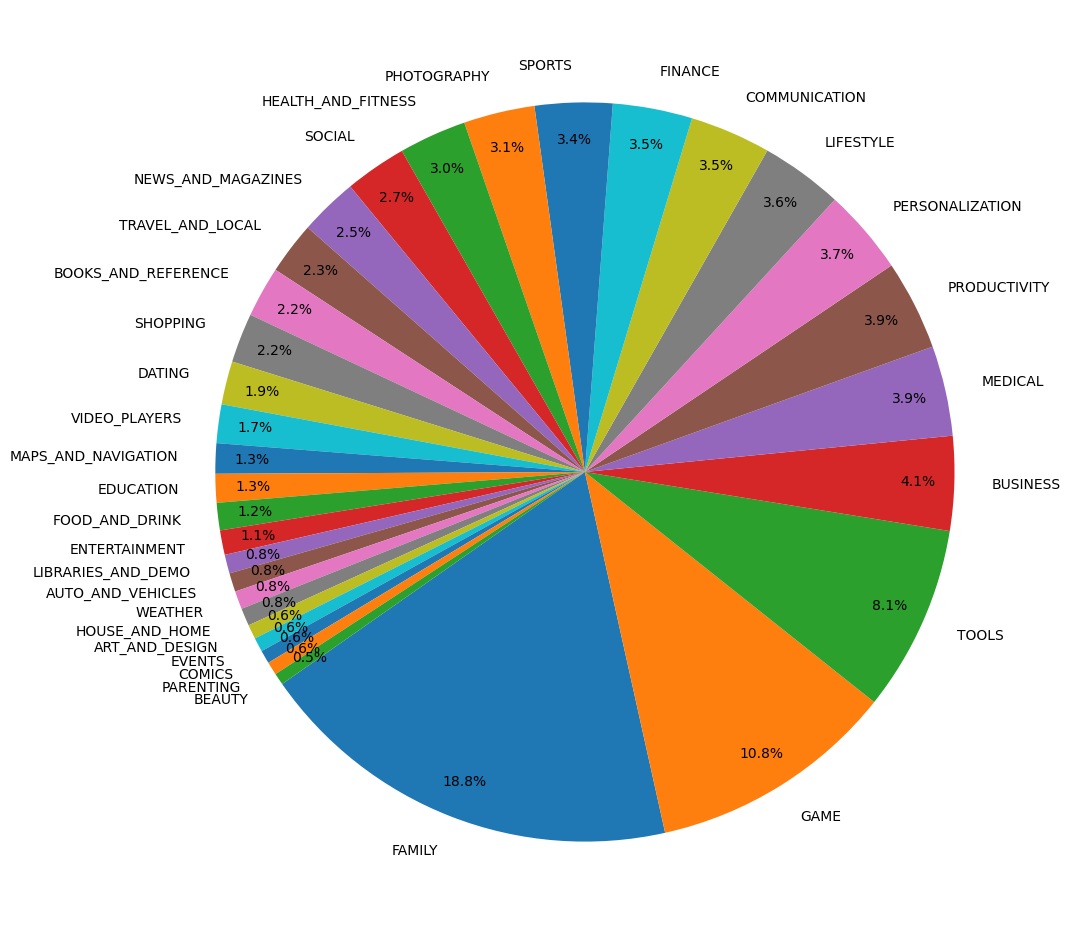

In [120]:
plt.figure(figsize=(12, 12))
plt.pie(quantidades_categorias, 
        labels=quantidades_categorias.index, 
        autopct='%1.1f%%', 
        startangle=215,
        pctdistance=0.9,
        labeldistance=1.1)
plt.show()

 - Função `unique()` utilizada para verificar como os valores foram inseridos na coluna `Price`

In [121]:
dados_google_Atualizado['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

- Função `str.replace()` utilizado para remover caracteres como `$` e `,` da coluna `Price` para remover o valor `Everyone` para um valor `Nulo`

- Função `astype()` utilzado para converter a coluna `Price` para `Float` 



In [122]:
dados_google_Atualizado['Price'] = dados_google_Atualizado['Price'].replace('[$,]','', regex=True)

dados_google_Atualizado['Price'] = dados_google_Atualizado['Price'].replace('Everyone', pd.NA)

dados_google_Atualizado['Price'] = dados_google_Atualizado['Price'].astype(float)


In [123]:
aplicativo_mais_caro = dados_google_Atualizado.loc[dados_google_Atualizado['Price'].idxmax()]

aplicativo_mais_caro

App               I'm Rich - Trump Edition
Category                         LIFESTYLE
Rating                                 3.6
Reviews                                275
Size                                  7.3M
Installs                             10000
Type                                  Paid
Price                                400.0
Content Rating                    Everyone
Genres                           Lifestyle
Last Updated                   May 3, 2018
Current Ver                          1.0.1
Android Ver                     4.1 and up
Name: 4367, dtype: object


- Função `unique()` utilizada para verificar como os valores foram inseridos na coluna `Content Rating`

In [124]:
dados_google_Atualizado['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [125]:
aplicativo_mature_17 = dados_google_Atualizado[dados_google_Atualizado['Content Rating'] == 'Mature 17+']

aplicativo_mature_17

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
129,"Secrets of beauty, youth and health",BEAUTY,NaN,77,2.9M,10000,Free,0.00,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up
133,Dresses Ideas & Fashions +3000,BEAUTY,4.5,473,8.2M,100000,Free,0.00,Mature 17+,Beauty,"March 1, 2017",1.0.2.0,1.6 and up
134,"Lady adviser (beauty, health)",BEAUTY,NaN,30,9.9M,10000,Free,0.00,Mature 17+,Beauty,"January 24, 2018",3.0,3.0 and up
166,Read books online,BOOKS_AND_REFERENCE,4.1,91615,23M,5000000,Free,0.00,Mature 17+,Books & Reference,"June 29, 2018",3.12,4.1 and up
170,Flybook,BOOKS_AND_REFERENCE,3.9,1778,4.9M,500000,Free,0.00,Mature 17+,Books & Reference,"October 16, 2014",1.0.3,2.1 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10735,FP VoiceBot,FAMILY,NaN,17,157k,100,Paid,0.99,Mature 17+,Entertainment,"November 25, 2015",1.2,2.1 and up
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622,Varies with device,100000,Free,0.00,Mature 17+,Social,"May 23, 2018",Varies with device,Varies with device
10783,Modern Counter Terror Attack – Shooting Game,GAME,4.2,340,72M,50000,Free,0.00,Mature 17+,Action,"October 27, 2017",1.0,4.1 and up
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486,Varies with device,5000000,Free,0.00,Mature 17+,Social,"March 23, 2018",Varies with device,Varies with device


 - Função `dropna()` utilizado para remover valores `Nulos` que podem conter na coluna `App` e `Reviews` 

 - Função `astype()` utilzado para converter a coluna `Reviews` para `Int` 

 - Função `groupby()` Utilizado para agrupar Apps com nomes repetidos em um só


In [126]:
coluna_review = dados_google_Atualizado[['App', 'Reviews']].dropna()  

coluna_review['Reviews'] = coluna_review['Reviews'].astype(int)

coluna_review_unico = coluna_review.groupby('App', as_index=False).max()

In [127]:

top_10_aplicativos_review = coluna_review_unico.sort_values(by='Reviews', ascending=False).head(10)

top_10_aplicativos_review

,App,Reviews
4328,Facebook,78158306
9041,WhatsApp Messenger,69119316
5399,Instagram,66577446
6165,Messenger – Text and Video Chat for Free,56646578
2564,Clash of Clans,44893888
2573,Clean Master- Space Cleaner & Antivirus,42916526
8079,Subway Surfers,27725352
9225,YouTube,25655305
7721,"Security Master - Antivirus, VPN, AppLock, Boo...",24900999
2561,Clash Royale,23136735


Quantos aplicativos são `Pagos` e quantos são `Free` ? 

- Função `unique()` utilizada para verificar como os valores foram inseridos na coluna `Type`

- Função `dropna()` utilizado para remover valores `Nulos` que podem conter na coluna `Type` 

- Função `value_counts()` utilizado para fazer a contagem de cada valor que foi inserido na coluna `Type`

In [128]:
dados_google_Atualizado['Type'].unique()

array(['Free', 'Paid', nan], dtype=object)

In [129]:
contagem_tipo = dados_google_Atualizado['Type'].dropna()

contagem_tipo = dados_google_Atualizado['Type'].value_counts()

Valores = contagem_tipo.values

Valores

array([9591,  765])

Quais os `5` maiores `Gêneros` que mais aparece no DataBase ?

- Função `value_counts()` utilizado para fazer a contagem de cada valor que foi inserido na coluna `Genres`

- Função `head()` utilizado para mostrar o topo com parâmetro de `5`

- Função `tolist()` utilizado para transformar em uma lista


In [130]:
frequencia_generos = dados_google_Atualizado['Genres'].value_counts()

top_5_generos = frequencia_generos.head(5)

top_5_generos_lista = top_5_generos.values.tolist()

top_5_generos_lista

[842, 588, 527, 427, 408]

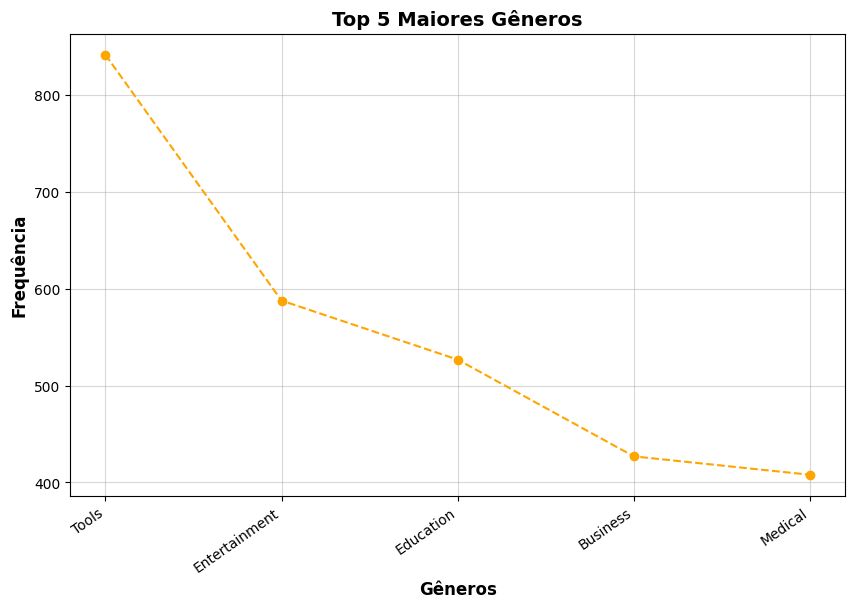

In [131]:
plt.figure(figsize=(10,6))
plt.plot(top_5_generos.index, top_5_generos.values, marker='o', linestyle='--', color='orange')
plt.title("Top 5 Maiores Gêneros", fontsize=14, fontweight='bold')
plt.ylabel("Frequência", fontsize=12, fontweight='bold')
plt.xlabel("Gêneros",fontsize=12, fontweight='bold')
plt.xticks(rotation= 35, ha='right')
plt.grid(True, linestyle='-', alpha=0.5)

plt.show()

 - `Aplicativos` retorna uma variável com os nomes dos aplicativos

 - `Reviews` retorna uma variável com o número de reviews

 - Função `tolist()` utilizado para transformar essas variáveis em uma lista

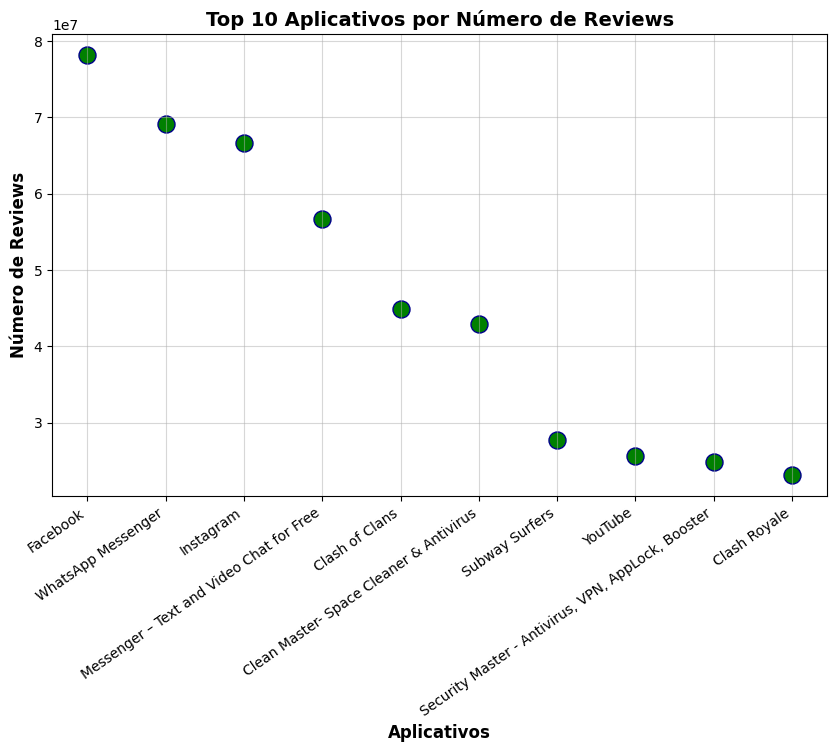

In [132]:
Aplicativos = top_10_aplicativos_review['App'].tolist()
Reviews = top_10_aplicativos_review['Reviews'].tolist()

plt.figure(figsize=(10, 6))
plt.scatter(Aplicativos, Reviews, color = 'green', s=150, edgecolor='darkblue')
plt.title("Top 10 Aplicativos por Número de Reviews", fontsize=14, fontweight='bold')
plt.ylabel("Número de Reviews", fontsize=12,fontweight='bold')
plt.xlabel("Aplicativos", fontsize=12,fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.grid(True, linestyle='-', alpha=0.5)

plt.show()